In [55]:
%load_ext autoreload
%autoreload 2
import torch
from training_functions import train
from mcnn import MCNN
import torch.nn as nn
import torch.optim as optim
from dataloader_mcnn import CrowdDataset
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import glob
import os
import numpy as np
import random
import time
SEED = 42
import caffe

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'caffe'

In [43]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [52]:
main_folders = [r"data\jhu_crowd_v2.0", r"data\NWPU-Crowd", r"data\ShanghaiTech_part_A", 
                r"data\ShanghaiTech_part_B", r"data\UCF-QNRF_ECCV18"]

train_datasets = []
val_datasets = []

for folder in main_folders:
    train_img_root = os.path.join(folder, "train", "images")
    train_map_root = os.path.join(folder, "train", "maps")
    
    if os.path.exists(train_img_root) and os.path.exists(train_map_root):
        print('ok')
        train_datasets.append(CrowdDataset(train_img_root, train_map_root, gt_downsample=4))
    
    val_img_root = os.path.join(folder, "val", "images")
    val_map_root = os.path.join(folder, "val", "maps")
    
    if os.path.exists(val_img_root) and os.path.exists(val_map_root):
        val_datasets.append(CrowdDataset(val_img_root, val_map_root, gt_downsample=4))

train_dataset = ConcatDataset(train_datasets)
val_dataset = ConcatDataset(val_datasets)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=4)

ok
ok
ok
ok
ok


In [54]:
set_seed(SEED)
model_dir = "output/models/mcnn"
history_dir = "output/history/mcnn"

os.makedirs(model_dir, exist_ok=True)
os.makedirs(history_dir, exist_ok=True)

model_path = model_dir + "/mcnn.pth"
history_path = history_dir + "/mcnn.pkl"

model = MCNN()
epochs = 100
tolerance = 5
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = criterion=nn.MSELoss(size_average=False).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-6)


start_time = time.time()
history = train(epochs, model, train_loader, val_loader, optimizer, criterion, device,model_path, tolerance = tolerance)
end_time = time.time()
print(f"total time: {end_time - start_time}\n")

KeyboardInterrupt: 

torch.Size([640, 976, 3]) torch.Size([40, 61, 1])
tensor(4512.2793)
torch.Size([448, 640, 3]) torch.Size([28, 40, 1])
tensor(627.6215)
torch.Size([736, 1024, 3]) torch.Size([46, 64, 1])
tensor(480.3258)
torch.Size([816, 1024, 3]) torch.Size([51, 64, 1])
tensor(560.1517)
torch.Size([672, 1024, 3]) torch.Size([42, 64, 1])
tensor(719.4807)
torch.Size([672, 1024, 3]) torch.Size([42, 64, 1])
tensor(2823.4819)


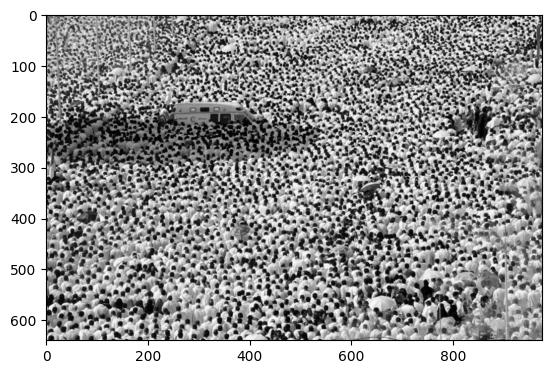

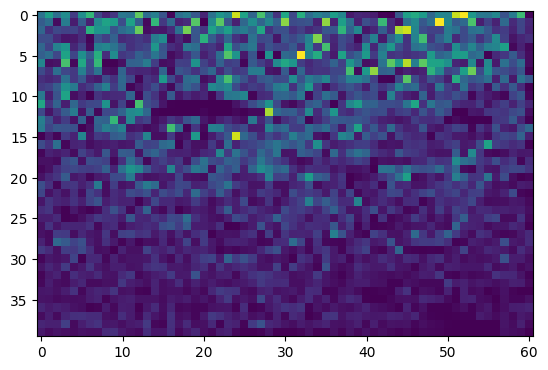

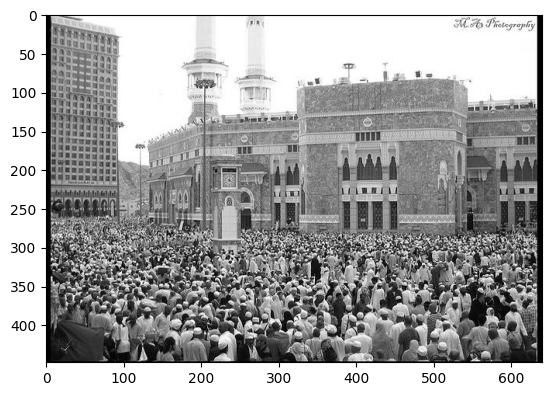

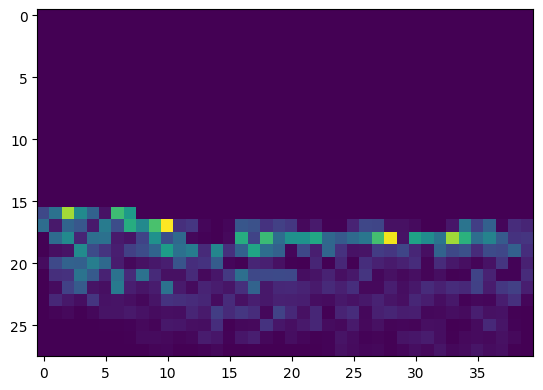

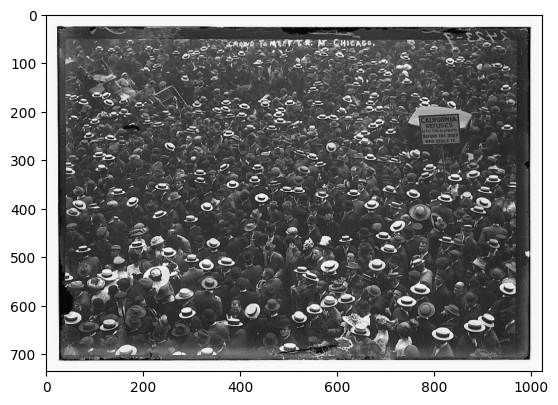

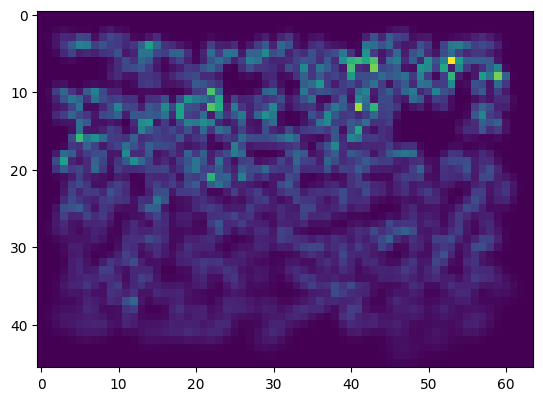

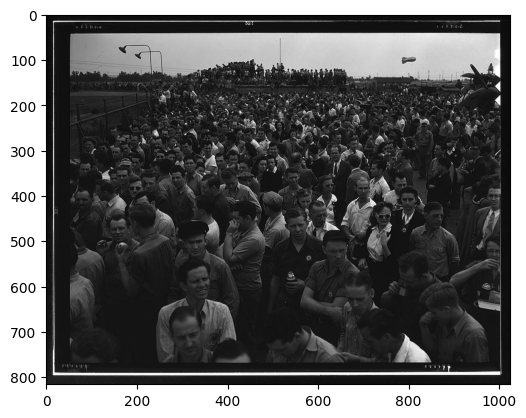

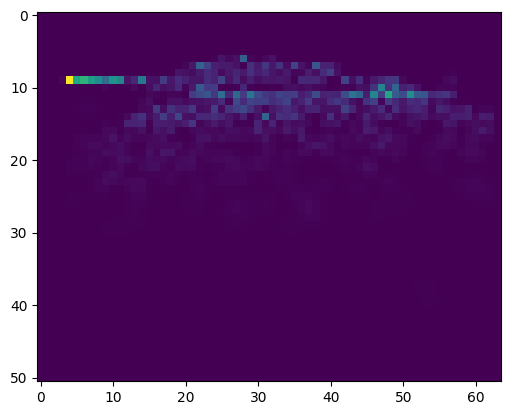

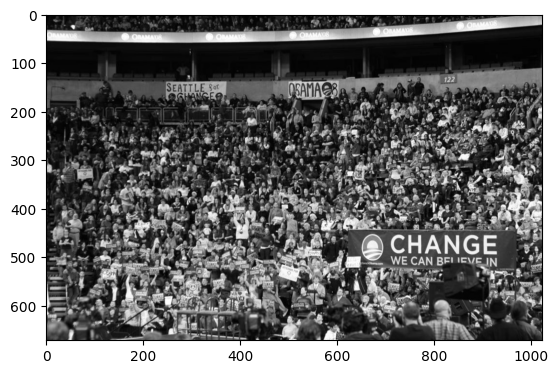

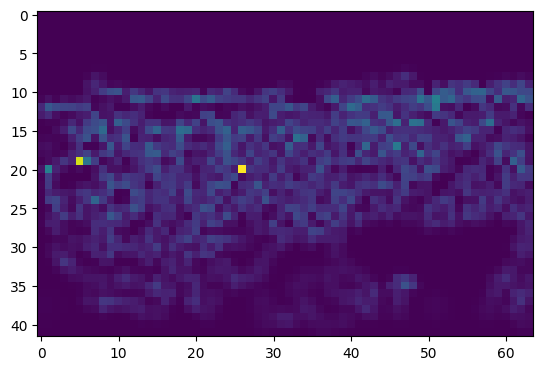

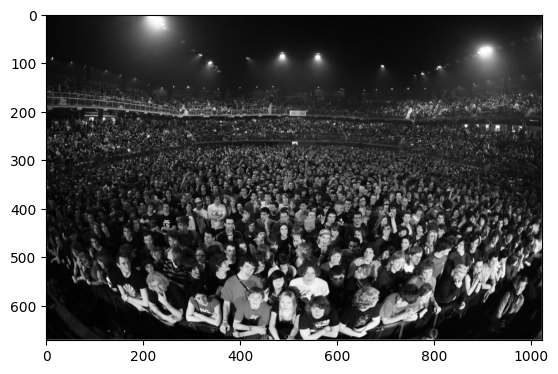

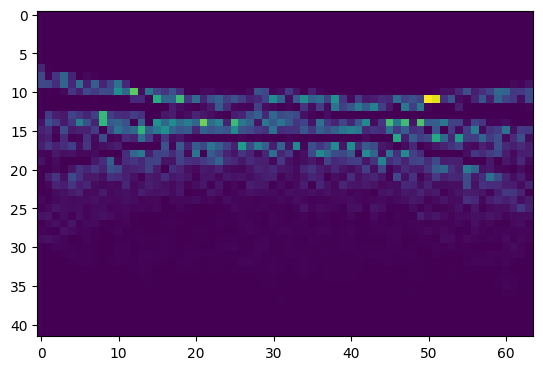

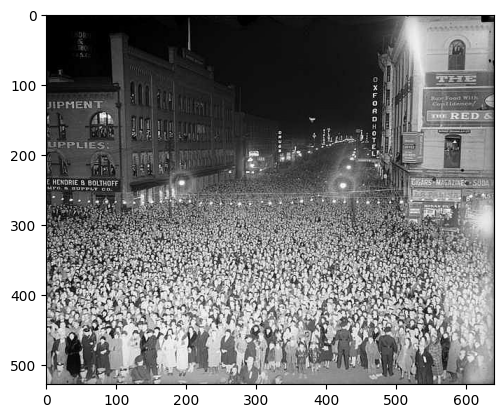

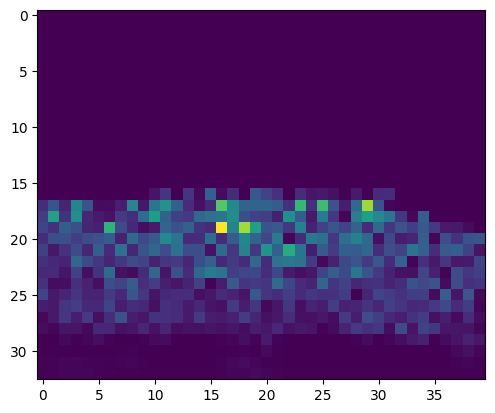

<Figure size 640x480 with 0 Axes>

In [ ]:
img_root=r'data\UCF_CC_50\images'
gt_map_path=r'data\UCF_CC_50\maps'
dataset=CrowdDataset(img_root,gt_map_path,gt_downsample=4)
for i,(img,gt_dmap) in enumerate(dataset):
    plt.imshow(img)
    plt.figure()
    plt.imshow(gt_dmap)
    plt.figure()
    if i>5:
        break
    print(img.shape,gt_dmap.shape)
    print(gt_dmap.sum())

In [7]:
import caffemodel2pytorch.caffe_pb2  # You can download caffe.proto and generate caffe_pb2.py with protoc
import google.protobuf.text_format as txtf
import numpy as np
import torch
import torch.nn as nn

def load_caffe_weights(caffemodel_path, model):
    from caffemodel2pytorch.caffe_pb2 import NetParameter

    net = NetParameter()
    with open(caffemodel_path, 'rb') as f:
        net.ParseFromString(f.read())

    # Map Caffe layers to PyTorch layers
    layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    ptr = 0
    for layer in net.layer:
        if layer.type != 'Convolution':
            continue
        weight = np.array(layer.blobs[0].data).reshape(layer.blobs[0].shape.dim)
        bias   = np.array(layer.blobs[1].data).reshape(layer.blobs[1].shape.dim)
        layers[ptr].weight.data = torch.from_numpy(weight)
        layers[ptr].bias.data   = torch.from_numpy(bias)
        ptr += 1

In [4]:
%load_ext autoreload
%autoreload 2
from CSRnet import CSRNet

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
model = CSRNet(load_weights=False)
load_caffe_weights("E:\\OneDrive\\Pulpit\\MSC-thesis\\output\\models\\csrnet\\shanghaia.caffemodel", model)
torch.save(model.state_dict(), "E:\\OneDrive\\Pulpit\\MSC-thesis\\output\\models\\csrnet\\shanghaia_converted.pth")
print("Saved shanghaia_converted.pth successfully!")

Saved shanghaia_converted.pth successfully!
